In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
input_file = "/data/elugos/event_embedding/train_20251214.csv"
# input_file = "../data/train_20251214.csv"
df = pd.read_csv(input_file)

/tmp/ipykernel_2806442/2695679303.py:3: DtypeWarning: Columns (40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file)


In [3]:
df.head()

,index,GlobalEventID,date,Year,Actor1Code,Actor1Name,Actor1CountryCode,Actor1EthnicCode,Actor2Code,Actor2Name,...,target,title,text,description,sbert_text_title,embedding_json_title,sbert_text,embedding_json,first_para,first_para_emb
0,0,1200203233,20240918,2024,USA,UNITED STATES,USA,NaN,CRM,GANG,...,bostonherald,Tren de Aragua gang started in Venezuela’s pri...,MIAMI (AP) — Former federal agent Was Tabor sa...,The gang has exploded into the presidential ca...,Tren de Aragua gang started in Venezuela’s pri...,"[-0.002818030072376132, -0.01742059737443924, ...",NaN,NaN,MIAMI (AP) — Former federal agent Was Tabor sa...,"[-0.08164525777101517, -0.027655666694045067, ..."
1,1,1200203234,20240918,2024,USA,FLORIDA,USA,NaN,GOV,ADMINISTRATION,...,bostonherald,Tren de Aragua gang started in Venezuela’s pri...,MIAMI (AP) — Former federal agent Was Tabor sa...,The gang has exploded into the presidential ca...,Tren de Aragua gang started in Venezuela’s pri...,"[-0.002818030072376132, -0.01742059737443924, ...",NaN,NaN,MIAMI (AP) — Former federal agent Was Tabor sa...,"[-0.08164525777101517, -0.027655666694045067, ..."
2,2,1200203284,20240925,2024,NaN,NaN,NaN,NaN,CHR,CHRISTIAN,...,brnow,"Yarnell: In times of competing allegiances, re...",NASHVILLE (BP) — The word “tumultuous” is one ...,NASHVILLE (BP) — The word “tumultuous” is one ...,"Yarnell: In times of competing allegiances, re...","[-0.0645490437746048, 0.05730828642845154, 0.0...",NaN,NaN,NASHVILLE (BP) — The word “tumultuous” is one ...,"[0.017953015863895416, -0.06336908042430878, -..."
3,3,1200203520,20240925,2024,NaN,NaN,NaN,NaN,USA,FLORIDA,...,yahoo,How Strong Could Hurricane Helene Get When It ...,Yahoo is using AI to generate takeaways from t...,Weather experts are expecting Hurricane Helene...,How Strong Could Hurricane Helene Get When It ...,"[-0.018027156591415405, 0.024802444502711296, ...",NaN,NaN,Yahoo is using AI to generate takeaways from t...,"[-0.018082909286022186, 0.06462761014699936, -..."
4,4,1200203521,20240925,2024,NaN,NaN,NaN,NaN,USA,FLORIDA,...,yahoo,How Strong Could Hurricane Helene Get When It ...,Yahoo is using AI to generate takeaways from t...,Weather experts are expecting Hurricane Helene...,How Strong Could Hurricane Helene Get When It ...,"[-0.018027156591415405, 0.024802444502711296, ...",NaN,NaN,Yahoo is using AI to generate takeaways from t...,"[-0.018082909286022186, 0.06462761014699936, -..."


In [15]:
# Drop CAMEO codes no loner used in PLOVER
df = df[~df['EventRootCode'].astype(str).isin({"1","2", "9"})]
df = df.drop_duplicates(subset=['title'])  # Drop duplicated titles
print(len(df))

37913


In [16]:
cameo_codes = {
    "MAKE PUBLIC STATEMENT": "1",
    "APPEAL": "2",
    "EXPRESS INTENT TO COOPERATE": "3",
    "CONSULT": "4",
    "ENGAGE IN DIPLOMATIC COOPERATION": "5",
    "ENGAGE IN MATERIAL COOPERATION": "6",
    "PROVIDE AID": "7",
    "YIELD": "8",
    "INVESTIGATE": "9",
    "DEMAND": "10",
    "DISAPPROVE": "11",
    "REJECT": "12",
    "THREATEN": "13",
    "PROTEST": "14",
    "EXHIBIT FORCE POSTURE": "15",
    "COERCE": "16",
    "ASSAULT": "17",
    "FIGHT": "19",
    "USE UNCONVENTIONAL MASS VIOLENCE": "20",
}

cameo_2_plover = {
    "03": "AGREE",
    "04": "CONSULT",
    "05": "SUPPORT",
    "06": "COOPERATE",
    "07": "AID",
    "81": "CONCEDE",
    "84": "RETREAT",
    "10": "DEMAND",
    "11": "DISAPPROVE",
    "12": "REJECT",
    "13": "THREATHEN",
    "14": "PROTEST",
    "15": "MOBILIZE",
    "16": "SANCTION",
    "17": "COERCE",
    "18": "ASSAULT",
    "19": "ASSAULT",
    "20": "ASSAULT"
}


def make_plover_codes(df: pd.DataFrame):
    """
    Make a Plover column from CAMEO's event codes.
    """
    evtcode_padded = df['EventBaseCode'].astype(str).str.zfill(3)
    # Replace 081-083 with 8.1 ("CONCEDE")
    evtcode_padded = evtcode_padded.str.replace(r"08[0-3]", "81", n=1, regex=True)
    evtcode_padded = evtcode_padded.str.replace(r"08[4-7]", "84", n=1, regex=True)
    
    plover_codes = evtcode_padded.str[:2].apply(lambda s: cameo_2_plover[s])
    return plover_codes

df['PloverCode'] = make_plover_codes(df)


In [17]:
df['EventLabel'] = df['PloverCode']

In [18]:
print(df.columns)

Index(['index', 'GlobalEventID', 'date', 'Year', 'Actor1Code', 'Actor1Name',
       'Actor1CountryCode', 'Actor1EthnicCode', 'Actor2Code', 'Actor2Name',
       'Actor2CountryCode', 'Actor2EthnicCode', 'IsRootEvent', 'EventCode',
       'EventBaseCode', 'EventRootCode', 'QuadClass', 'GoldsteinScale',
       'NumMentions', 'NumSources', 'NumArticles', 'AvgTone',
       'Actor1Geo_CountryCode', 'Actor2Geo_CountryCode', 'ActionGeo_Type',
       'ActionGeo_Fullname', 'ActionGeo_CountryCode', 'ActionGeo_ADM1Code',
       'ActionGeo_Lat', 'ActionGeo_Long', 'ActionGeo_FeatureID', 'DATEADDED',
       'SOURCEURL', 'domain', 'target', 'title', 'text', 'description',
       'sbert_text_title', 'embedding_json_title', 'sbert_text',
       'embedding_json', 'first_para', 'first_para_emb', 'PloverCode',
       'EventLabel'],
      dtype='object')


In [19]:
print(df['EventLabel'].value_counts())

EventLabel
CONSULT       8951
ASSAULT       4950
DISAPPROVE    4687
SUPPORT       3718
COERCE        2970
AGREE         2770
AID           2017
REJECT        1475
CONCEDE       1136
COOPERATE     1106
RETREAT       1066
THREATHEN     1031
DEMAND         725
PROTEST        700
SANCTION       458
MOBILIZE       153
Name: count, dtype: int64


Event count:
    Average=2369.5625
    Std. dev=2225.937048996164


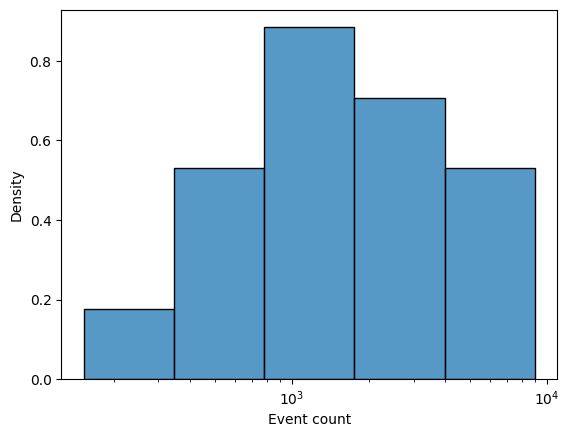

In [20]:
event_counts = df['EventLabel'].value_counts()
sns.histplot(data=event_counts, log_scale=True, stat='density')
plt.xlabel("Event count");

evt_count_avg = event_counts.values.mean()
evt_count_std = event_counts.values.std()
print(f"Event count:")
print(f"    Average={evt_count_avg}")
print(f"    Std. dev={evt_count_std}")


# Event count distribution: log-normal?

/tmp/ipykernel_2806442/120193414.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=45);


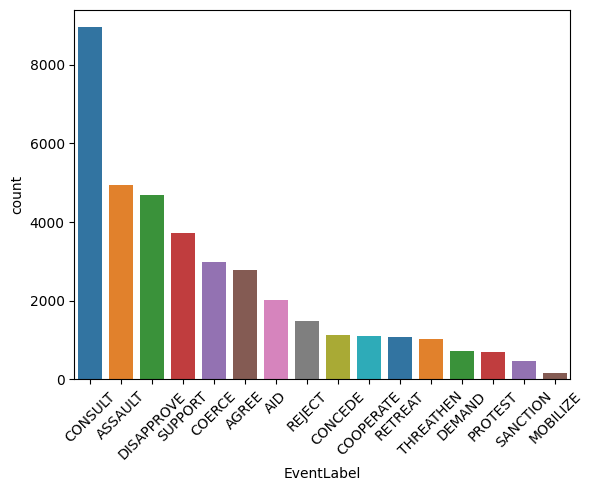

In [21]:
event_count_df = event_counts.reset_index()
plot = sns.barplot(data=event_count_df, x='EventLabel', y='count', hue='EventLabel', palette='tab10', legend=False);
plot.set_xticklabels(plot.get_xticklabels(), rotation=45);


/tmp/ipykernel_2806442/3040765560.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=45);


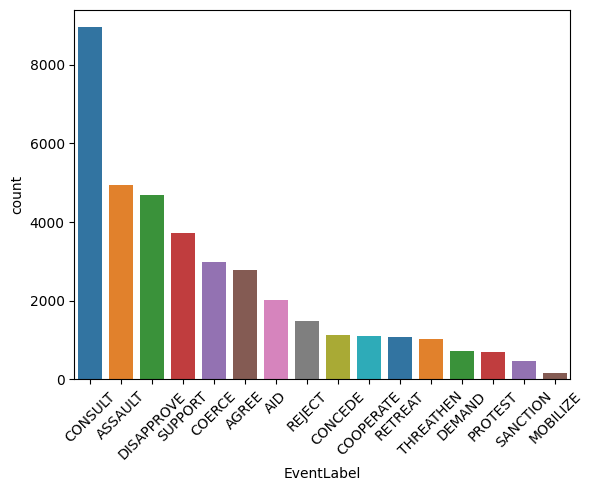

In [22]:
# Events with count >= n
n = 50
event_count_df_cutoff = event_counts[event_counts>n].reset_index()
plot = sns.barplot(data=event_count_df_cutoff, x='EventLabel', y='count', hue='EventLabel', palette='tab10', legend=False);
plot.set_xticklabels(plot.get_xticklabels(), rotation=45);


In [23]:
from datetime import datetime
# df.drop('level_0', axis=1, inplace=True)
df.to_csv(f"/data/elugos/event_embedding/train_{datetime.now().strftime("%Y%m%d%H%M%S")}.csv", index=None)

In [24]:
# Actor1 distribution

print(df['Actor1Code'].value_counts())
print(df['Actor2Code'].value_counts())

Actor1Code
USA                8210
GOV                2679
BUS                1699
COP                1470
CVL                1465
                   ... 
RUSGOVGOVJUD          1
JAMEDU                1
IRLGOV                1
FRAMED                1
NGOINDTAMRELHLH       1
Name: count, Length: 743, dtype: int64
Actor2Code
USA       9472
GOV       1746
CVL       1093
BUS       1052
USAGOV     854
          ... 
MOSOPP       1
ISRHLH       1
IRQCOP       1
VATMED       1
UAFBUS       1
Name: count, Length: 681, dtype: int64
